In [7]:
import pandas as pd
data=pd.read_csv("/content/sample_data/tv_show_prediction_dataset.csv")
data

,title,country,release_year,release_decade,rating,is_adult,num_seasons,is_drama,is_comedy,is_crime,is_reality,is_international,listed_in,renewed
0,Blood & Water,South Africa,2021,2020,TV-MA,1,2.0,1,0,0,0,1,"International TV Shows, TV Dramas, TV Mysteries",1
1,Ganglands,NaN,2021,2020,TV-MA,1,1.0,0,0,1,0,1,"Crime TV Shows, International TV Shows, TV Act...",0
2,Jailbirds New Orleans,NaN,2021,2020,TV-MA,1,1.0,0,0,0,1,0,"Docuseries, Reality TV",0
3,Kota Factory,India,2021,2020,TV-MA,1,2.0,0,0,0,0,1,"International TV Shows, Romantic TV Shows, TV ...",1
4,Midnight Mass,NaN,2021,2020,TV-MA,1,1.0,1,0,0,0,0,"TV Dramas, TV Horror, TV Mysteries",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2671,Yu-Gi-Oh! Arc-V,"Japan, Canada",2015,2010,TV-Y7,0,2.0,0,0,0,0,0,"Anime Series, Kids' TV",1
2672,Yunus Emre,Turkey,2016,2010,TV-PG,0,2.0,1,0,0,0,1,"International TV Shows, TV Dramas",1
2673,Zak Storm,"United States, France, South Korea, Indonesia",2016,2010,TV-Y7,0,3.0,0,0,0,0,0,Kids' TV,1
2674,Zindagi Gulzar Hai,Pakistan,2012,2010,TV-PG,0,1.0,1,0,0,0,1,"International TV Shows, Romantic TV Shows, TV ...",0


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
print(data.head())



                   title       country  release_year  release_decade rating  \
0          Blood & Water  South Africa          2021            2020  TV-MA   
1              Ganglands           NaN          2021            2020  TV-MA   
2  Jailbirds New Orleans           NaN          2021            2020  TV-MA   
3           Kota Factory         India          2021            2020  TV-MA   
4          Midnight Mass           NaN          2021            2020  TV-MA   

   is_adult  num_seasons  is_drama  is_comedy  is_crime  is_reality  \
0         1          2.0         1          0         0           0   
1         1          1.0         0          0         1           0   
2         1          1.0         0          0         0           1   
3         1          2.0         0          0         0           0   
4         1          1.0         1          0         0           0   

   is_international                                          listed_in  \
0                 1    I

In [9]:
print(data.isnull().sum())

data = data.drop_duplicates()


title                 0
country             391
release_year          0
release_decade        0
rating                2
is_adult              0
num_seasons           0
is_drama              0
is_comedy             0
is_crime              0
is_reality            0
is_international      0
listed_in             0
renewed               0
dtype: int64


In [11]:
data["is_drama"] = data["is_drama"].fillna(0)
data["is_comedy"] = data["is_comedy"].fillna(0)
data["is_crime"] = data["is_crime"].fillna(0)
data["is_reality"] = data["is_reality"].fillna(0)
data["num_seasons"] = data["num_seasons"].fillna(0)


In [14]:
le = LabelEncoder()

data["is_drama"] = le.fit_transform(data["is_drama"])
data["is_comedy"] = le.fit_transform(data["is_comedy"])
data["is_crime"] = le.fit_transform(data["is_crime"])
data["is_reality"] = le.fit_transform(data["is_reality"])
data["num_seasons"] = le.fit_transform(data["num_seasons"])

In [15]:
x = data[[
    "is_drama",
    "is_comedy",
    "is_crime",
    "is_reality",
    "num_seasons"
]]

y = data["renewed"]

In [16]:
model = BernoulliNB()

model.fit(x, y)


BernoulliNB()

In [18]:
y_pred = model.predict(x)

In [19]:
accuracy = accuracy_score(y, y_pred)

print("Accuracy =", accuracy * 100)


Accuracy = 100.0


[[1793    0]
 [   0  883]]


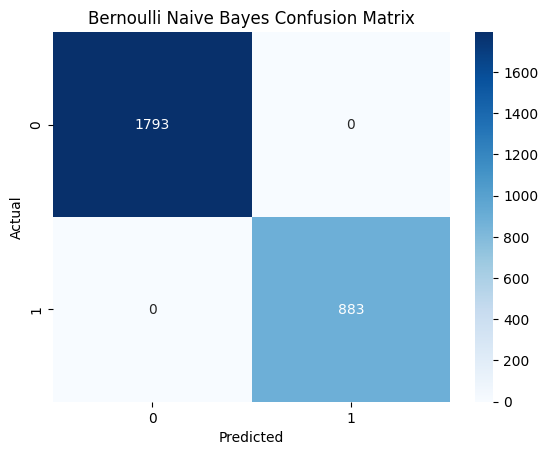

In [20]:
cm = confusion_matrix(y, y_pred)

print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Bernoulli Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
print("\nEnter TV Show Details")

is_drama = int(input("Drama (0/1): "))
is_comedy = int(input("Comedy (0/1): "))
is_crime = int(input("Crime (0/1): "))
is_reality = int(input("Reality (0/1): "))
num_seasons= int(input("num_seasons (0/1): "))

new_data = [[
    is_drama,
    is_comedy,
    is_crime,
    is_reality,
    num_seasons
]]

prediction = model.predict(new_data)

if prediction[0] == 1:
    print("\nTV Show will be Renewed")
else:
    print("\nTV Show will NOT be Renewed")



Enter TV Show Details
Drama (0/1): 0
Comedy (0/1): 0
Crime (0/1): 0
Reality (0/1): 1
num_seasons (0/1): 1

TV Show will be Renewed


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(
